In [309]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_regression

In [310]:
pd.set_option('display.max_columns', None)

train_df = pd.read_csv('../data/train.csv')
test_df = pd.read_csv('../data/test.csv')

print(f"Dataset de Treino: {train_df.shape}")
print(f"Dataset de Teste: {test_df.shape}")

Dataset de Treino: (1460, 81)
Dataset de Teste: (1459, 80)


In [311]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [312]:
train_df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1379.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,46.549315,567.240411,1057.429452,1162.626712,346.992466,5.844521,1515.463699,0.425342,0.057534,1.565068,0.382877,2.866438,1.046575,6.517808,0.613014,1978.506164,1.767123,472.980137,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,161.319273,441.866955,438.705324,386.587738,436.528436,48.623081,525.480383,0.518911,0.238753,0.550916,0.502885,0.815778,0.220338,1.625393,0.644666,24.689725,0.747315,213.804841,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,0.000000,0.000000,334.000000,0.000000,0.000000,334.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,1900.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,0.000000,223.000000,795.750000,882.000000,0.000000,0.000000,1129.500000,0.000000,0.000000,1.000000,0.000000,2.000000,1.000000,5.000000,0.000000,1961.000000,1.000000,334.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,0.000000,477.500000,991.500000,1087.000000,0.000000,0.000000,1464.000000,0.000000,0.000000,2.000000,0.000000,3.000000,1.000000,6.000000,1.000000,1980.000000,2.000000,480.000000,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,0.000000,808.000000,1298.250000,1391.250000,728.000000,0.000000,1776.750000,1.000000,0.000000,2.000000,1.000000,3.000000,1.000000,7.000000,1.000000,2002.000000,2.000000,576.000000,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1474.000000,2336.000000,6110.000000,4692.000000,2065.000000,572.000000,5642.000000,3.000000,2.000000,3.000000,2.000000,8.000000,3.000000,14.000000,3.000000,2010.000000,4.000000,1418.000000,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [313]:
# Contagem de valores nulos
missing_values = train_df.isnull().sum()
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)
print("Colunas com valores nulos:\n", missing_values)

Colunas com valores nulos:
 PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtFinType1      37
BsmtCond          37
BsmtQual          37
MasVnrArea         8
Electrical         1
dtype: int64


## Análise da Variável Alvo

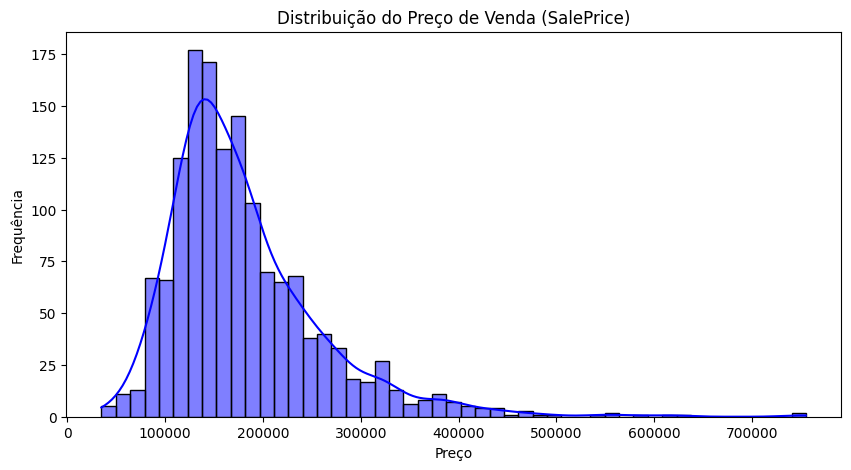

Assimetria (Skewness): 1.88


In [314]:
plt.figure(figsize=(10, 5))
sns.histplot(train_df['SalePrice'], kde=True, color='blue')
plt.title('Distribuição do Preço de Venda (SalePrice)')
plt.xlabel('Preço')
plt.ylabel('Frequência')
plt.show()

print(f"Assimetria (Skewness): {train_df['SalePrice'].skew():.2f}")

## Identificação de Valores Faltantes

In [315]:
train_df.info()

# Contagem de valores nulos em ordem decrescente (apenas as top 15)
null_counts = train_df.isnull().sum().sort_values(ascending=False)
print("\nTop 15 colunas com valores faltantes:")
print(null_counts.head(15))

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

## Tratamento de Outliers

In [316]:
outliers = train_df[(train_df['GrLivArea'] > 4000) & (train_df['SalePrice'] < 300000)].index
train_df = train_df.drop(outliers)

print(f"Novo formato do dataset após remoção de outliers: {train_df.shape}")

Novo formato do dataset após remoção de outliers: (1458, 81)


## Análise de Correlação

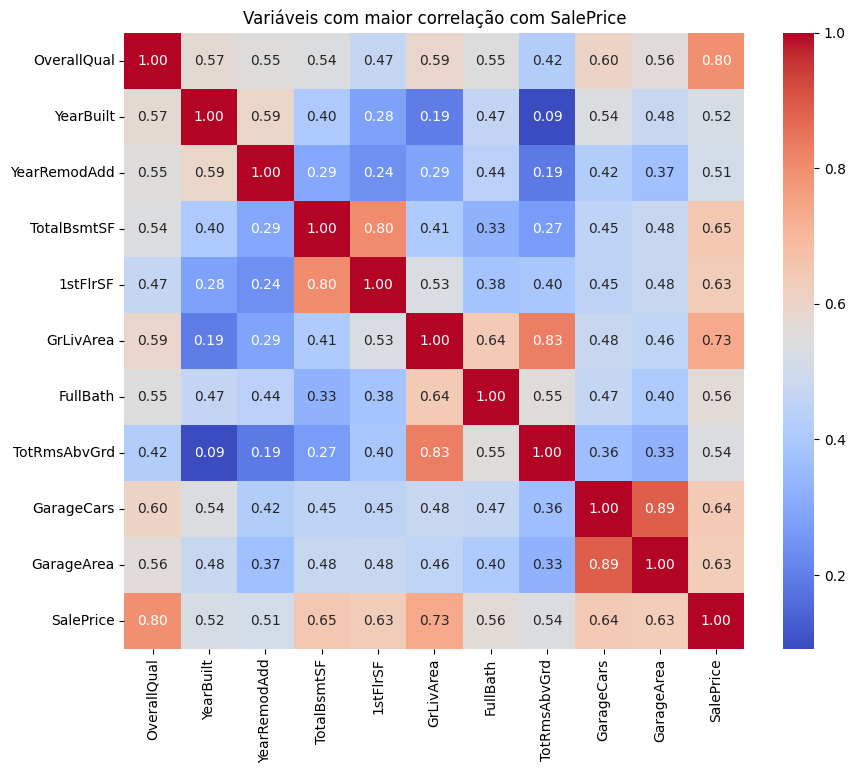

In [317]:
# seleciona apenas variáveis numéricas
numeric_train = train_df.select_dtypes(include=[np.number])

# calculcula correlação e filtrar as mais fortes (maior que 0.5 ou menor que -0.5)
corr = numeric_train.corr()
top_corr_features = corr.index[abs(corr["SalePrice"]) > 0.5]

plt.figure(figsize=(10, 8))
sns.heatmap(train_df[top_corr_features].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Variáveis com maior correlação com SalePrice")
plt.show()

## Tratamento de Valores Faltantes (Início da Engenharia de Features)

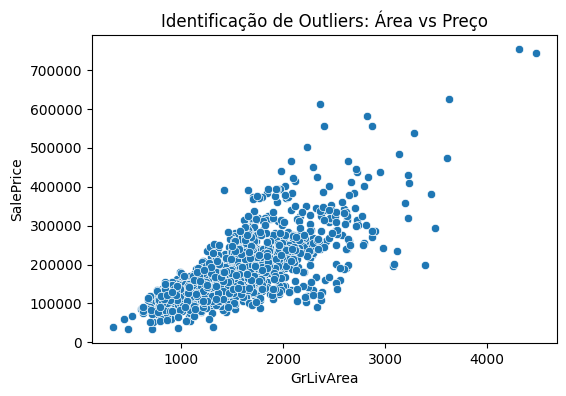

In [318]:
plt.figure(figsize=(6, 4))
sns.scatterplot(x=train_df['GrLivArea'], y=train_df['SalePrice'])
plt.title('Identificação de Outliers: Área vs Preço')
plt.show()

# remove imóveis com mais de 4000 de área, mas preço muito baixo
outliers = train_df[(train_df['GrLivArea'] > 4000) & (train_df['SalePrice'] < 300000)].index
train_df = train_df.drop(outliers)

# Imputação de Valores Faltantes nas variáveis numéricas
numeric_cols = train_df.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    if train_df[col].isnull().sum() > 0:
        train_df[col] = train_df[col].fillna(train_df[col].median())
        
# drop colunas categóricas com excesso de nulos
train_df = train_df.dropna(axis=1, thresh=len(train_df)*0.8)

## Transformação de Variáveis (Tratamento da Assimetria)

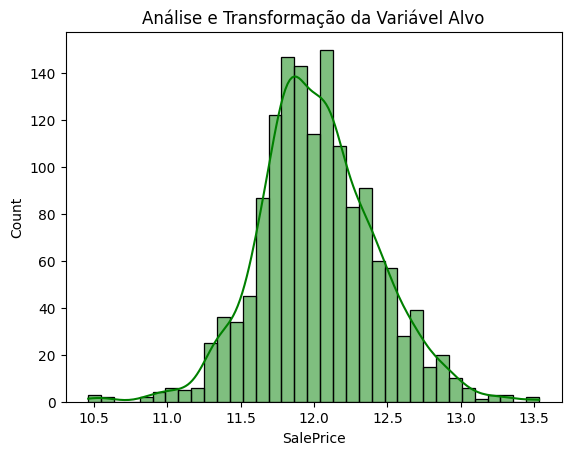

In [319]:
# Aplicando a transformação logarítmica na variável alvo
train_df['SalePrice'] = np.log1p(train_df['SalePrice'])

# Plotando novamente para conferir a nova distribuição
sns.histplot(train_df['SalePrice'], kde=True, color='green')
plt.title('Análise e Transformação da Variável Alvo')
plt.show()

## Codificação de Variáveis Categóricas

In [320]:
train_df['Idade_Imovel'] = train_df['YrSold'] - train_df['YearBuilt']

y = np.log1p(train_df['SalePrice'])
X = train_df.drop(columns=['SalePrice', 'Id'], errors='ignore')

X_encoded = pd.get_dummies(X, drop_first=True)

# Preencher possíveis nulos gerados nas categóricas restantes com 0
X_encoded = X_encoded.fillna(0)

# Normalização das Variáveis
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_encoded)

# Reconstruindo o dataframe
X_final = pd.DataFrame(X_scaled, columns=X_encoded.columns)
print(f"Dataset final pronto para os modelos: {X_final.shape}")

Dataset final pronto para os modelos: (1458, 229)


## Seleção de Features (Feature Selection)

In [321]:
# seleciona as 50 melhores features usando teste estatístico (f_regression)
selector = SelectKBest(score_func=f_regression, k=50)
X_selected = selector.fit_transform(X_final, y)

# pegando os nomes das colunas selecionadas para manter a rastreabilidade
selected_mask = selector.get_support()
selected_features = X_final.columns[selected_mask]

X_best = pd.DataFrame(X_selected, columns=selected_features)

print("As top 5 features selecionadas foram:")
print(selected_features[:5].tolist())

As top 5 features selecionadas foram:
['LotFrontage', 'LotArea', 'OverallQual', 'YearBuilt', 'YearRemodAdd']


# **Modelagem de Regressão Linear Multipla**

In [322]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

X_train, X_test, y_train, y_test = train_test_split(X_best, y, test_size=0.2, random_state=42)

print(f"Tamanho dos dados de Treino: {X_train.shape[0]} imóveis")
print(f"Tamanho dos dados de Teste: {X_test.shape[0]} imóveis")

Tamanho dos dados de Treino: 1166 imóveis
Tamanho dos dados de Teste: 292 imóveis


## Treinamento de modelo de Linear

In [323]:
modelo_lr = LinearRegression()
modelo_lr.fit(X_train, y_train)
previsoes_log = modelo_lr.predict(X_test)

print(" Modelo de Regressão Linear treinado com sucesso!")

 Modelo de Regressão Linear treinado com sucesso!


## Avaliação de Desempenho

 Resultados da Avaliação (Regressão Linear):
--------------------------------------------------
R² (Poder de explicação): 0.8761 (87.61%)
MAE (Erro Absoluto Médio): US$ 0.10
RMSE (Raiz do Erro Quadrático Médio): US$ 0.14


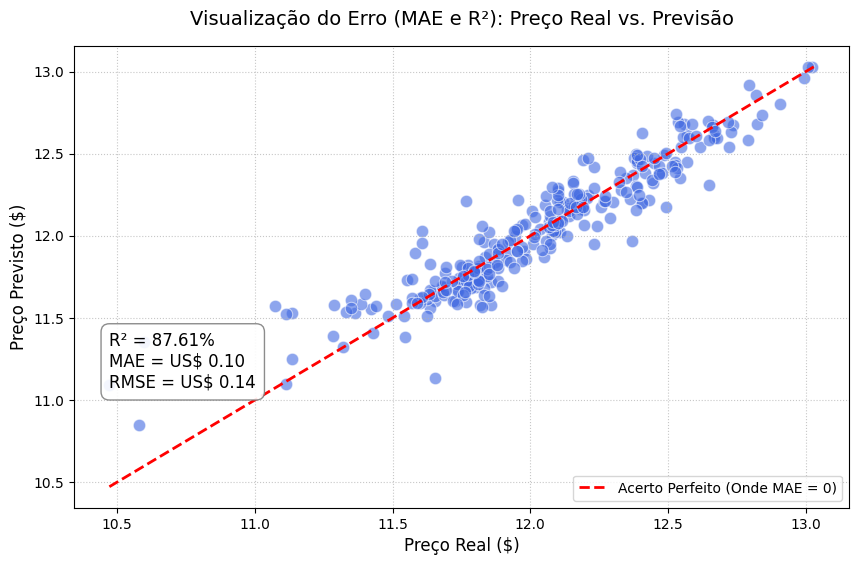

In [324]:
import matplotlib.pyplot as plt
import seaborn as sns


y_test_real = np.expm1(y_test)
previsoes_real = np.expm1(previsoes_log)

# Calculando as métricas
r2 = r2_score(y_test_real, previsoes_real)
mae = mean_absolute_error(y_test_real, previsoes_real)
rmse = np.sqrt(mean_squared_error(y_test_real, previsoes_real))

print(" Resultados da Avaliação (Regressão Linear):")
print("-" * 50)
print(f"R² (Poder de explicação): {r2:.4f} ({(r2*100):.2f}%)")
print(f"MAE (Erro Absoluto Médio): US$ {mae:,.2f}")
print(f"RMSE (Raiz do Erro Quadrático Médio): US$ {rmse:,.2f}") 

# Grafico visualizando o erro entre os valores
plt.figure(figsize=(10, 6))

sns.scatterplot(x=y_test_real, y=previsoes_real, alpha=0.6, color='royalblue', edgecolor='w', s=80)

min_val = min(y_test_real.min(), previsoes_real.min())
max_val = max(y_test_real.max(), previsoes_real.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Acerto Perfeito (Onde MAE = 0)')

texto_metricas = f"R² = {(r2*100):.2f}%\nMAE = US$ {mae:,.2f}\nRMSE = US$ {rmse:,.2f}"
plt.text(x=min_val, y=max_val*0.85, s=texto_metricas, fontsize=12, 
         bbox=dict(facecolor='white', alpha=0.9, edgecolor='gray', boxstyle='round,pad=0.5'))

plt.title('Visualização do Erro (MAE e R²): Preço Real vs. Previsão', fontsize=14, pad=15)
plt.xlabel('Preço Real ($)', fontsize=12)
plt.ylabel('Preço Previsto ($)', fontsize=12)
plt.legend(loc='lower right')
plt.grid(True, linestyle=':', alpha=0.7)

plt.show()

# **Modelo de classificação (Preço baixo e Preço alto)**

In [ ]:
import numpy as np

mediana_preco = y.median()
y_binario = (y > mediana_preco).astype(int)

preco_real_corte = np.expm1(mediana_preco) 
print(f"Ponto de corte (Mediana): US$ {preco_real_corte:,.2f}")
print("-" * 40)
print("Distribuição das Classes:")
print(y_binario.value_counts().rename(index={0: 'Baixo (0)', 1: 'Alto (1)'}))

Ponto de corte (Mediana): US$ 12.00
----------------------------------------
Distribuição das Classes:
SalePrice
Baixo (0)    731
Alto (1)     727
Name: count, dtype: int64


## Divisão dos dados e Treinamento de modelo

In [326]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X_train_class, X_test_class, y_train_class, y_test_class = train_test_split(
    X_best, y_binario, test_size=0.2, random_state=42
)

modelo_classificacao = LogisticRegression(max_iter=1000)
modelo_classificacao.fit(X_train_class, y_train_class)
previsoes_class = modelo_classificacao.predict(X_test_class)

print("Modelo de Classificação treinado com sucesso!")

Modelo de Classificação treinado com sucesso!


## Avaliação de Desempenho

Resultados da Avaliação (Classificação):
--------------------------------------------------
Acurácia (Taxa de Acerto Geral): 0.9315 (93.15%)

Relatório de Classificação Completo:
                 precision    recall  f1-score   support

Preço Baixo (0)       0.94      0.92      0.93       141
 Preço Alto (1)       0.93      0.94      0.93       151

       accuracy                           0.93       292
      macro avg       0.93      0.93      0.93       292
   weighted avg       0.93      0.93      0.93       292



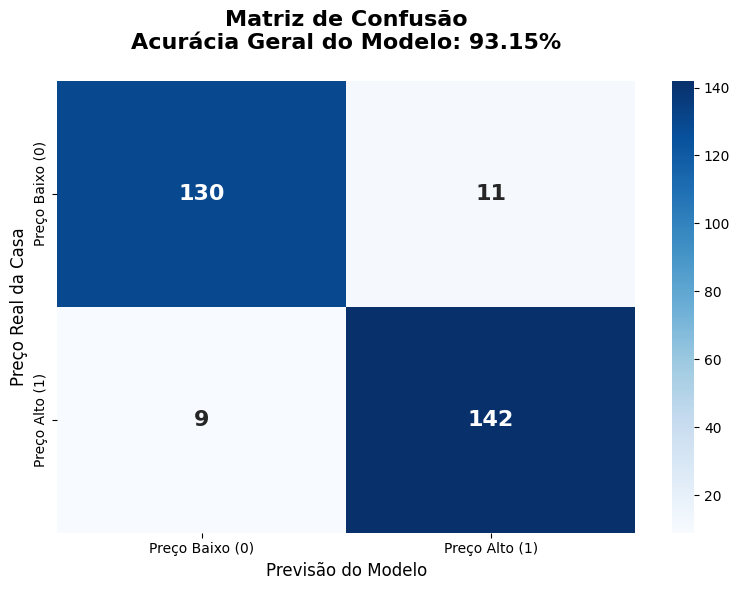

In [328]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


# Calculando a Acurácia e a Matriz
acuracia = accuracy_score(y_test_class, previsoes_class)
matriz = confusion_matrix(y_test_class, previsoes_class)

print("Resultados da Avaliação (Classificação):")
print("-" * 50)
print(f"Acurácia (Taxa de Acerto Geral): {acuracia:.4f} ({(acuracia*100):.2f}%)\n")

print("Relatório de Classificação Completo:")
print(classification_report(y_test_class, previsoes_class, target_names=['Preço Baixo (0)', 'Preço Alto (1)']))

# Grafico da Matriz de Confusão com a Acurácia
plt.figure(figsize=(8, 6))

sns.heatmap(matriz, annot=True, fmt='g', cmap='Blues', 
            annot_kws={"size": 16, "weight": "bold"}, # Números grandes e em negrito
            xticklabels=['Preço Baixo (0)', 'Preço Alto (1)'], 
            yticklabels=['Preço Baixo (0)', 'Preço Alto (1)'])

plt.title(f'Matriz de Confusão\nAcurácia Geral do Modelo: {(acuracia*100):.2f}%\n', 
          fontsize=16, fontweight='bold')

plt.xlabel('Previsão do Modelo', fontsize=12)
plt.ylabel('Preço Real da Casa', fontsize=12)

plt.tight_layout()
plt.show()